In [1]:
import json
import pandas as pd

In [2]:

with open('data/dataset.json') as file:
    data = json.loads(file.read())

In [3]:
df = pd.DataFrame(data)

In [4]:
df.head()

,author,kind,genre,title,text
0,Adam_Mickiewicz,Dramat,Dramat_romantyczny,"Dziady, część II",DZIADY. Jest to nazwisko uroczystości obchodzo...
1,Adam_Mickiewicz,Dramat,Dramat_romantyczny,"Dziady, część II","Mów, czego trzeba dla duszy,\nAby się dostać d..."
2,Adam_Mickiewicz,Dramat,Dramat_romantyczny,"Dziady, część III","spółuczniom, spółwięźniom, spółwygnańcom\nza m..."
3,Adam_Mickiewicz,Dramat,Dramat_romantyczny,"Dziady, część III","I skądże się tu wziąłeś, Żegoto kochany? Kiedy..."
4,Adam_Mickiewicz,Dramat,Dramat_romantyczny,"Dziady, część III",Spojrzałem w kościół pusty i rękę kapłańską\nW...


In [5]:
df.value_counts(subset=['author', 'kind'])

author             kind  
Juliusz_Słowacki   Dramat    71
Zygmunt_Krasiński  Epika     70
Adam_Mickiewicz    Epika     50
                   Dramat    21
Zygmunt_Krasiński  Dramat     1
Name: count, dtype: int64

In [6]:
df['author'].value_counts()

author
Adam_Mickiewicz      71
Juliusz_Słowacki     71
Zygmunt_Krasiński    71
Name: count, dtype: int64

### Ważne: brakuje kombinacji SłowackixEpika

# Pytanie 1

In [7]:
from pytania_badawcze.pytanie_1.evaluation import evaluate_no_genre_control, evaluate_with_genre_control, statistical_tests, run_experiment, print_report
from pytania_badawcze.pytanie_1.preprocessig import build_chunk_dataset
from pytania_badawcze.pytanie_1.plots import plot_results
from sklearn.feature_extraction.text import TfidfVectorizer


In [8]:
print("Budowanie zbioru...")
df_chunks = build_chunk_dataset(df)
print(f"  Chunki: {len(df_chunks)} fragmentów z {df['title'].nunique()} tytułów")


vectorizer_cfg = {
    "word_unigram": TfidfVectorizer(analyzer="word", ngram_range=(1, 1)),
}

Budowanie zbioru...
  Chunki: 850 fragmentów z 18 tytułów


In [9]:
exp_result = run_experiment(df_chunks, TfidfVectorizer(analyzer="word", ngram_range=(1, 1)), "word_unigram")


Wektoryzacja: word_unigram


In [10]:
exp_result

{'vectorizer': 'word_unigram',
 'f1_no': array([0.02276423, 0.30783242, 0.49272492, 0.25973207, 0.43399512]),
 'acc_no': array([0.03535354, 0.85786802, 0.50322581, 0.36241611, 0.58940397]),
 'gmean_no': array([0.06377339, 0.42082004, 0.68677784, 0.52631545, 0.56794026]),
 'f1_gen': array([1.        , 0.46176471, 0.        , 0.26495726, 0.48717949,
        0.00502513, 0.32534247, 0.20731707, 0.43434343, 1.        ]),
 'acc_gen': array([1.        , 0.70491803, 0.        , 0.63265306, 0.95      ,
        0.00505051, 0.4822335 , 0.26153846, 0.76785714, 1.        ]),
 'gmean_gen': array([0.        , 0.51614987, 0.        , 0.4796173 , 0.475     ,
        0.00252525, 0.24111675, 0.13076923, 0.38392857, 0.        ]),
 'per_genre': [{'genre': 'Dramat',
   'authors': ['Adam_Mickiewicz', 'Juliusz_Słowacki', 'Zygmunt_Krasiński'],
   'n_chunks': 278,
   'n_titles': 10,
   'n_folds': 5,
   'f1_mean': np.float64(0.44278029160382093),
   'f1_std': np.float64(0.3287859228789744),
   'acc_mean': np.flo

In [11]:
print_report(exp_result)


WYNIKI

Wektoryzacja: word_unigram

[F1-score macro]
Bez kontroli gatunku: 0.3034 ± 0.1635
Z kontrolą gatunku: 0.4428 ± 0.3288
Delta: +0.1394
Paired t-test: t=-0.5871, p=0.5887
Wilcoxon: W=4.0000, p=0.4375

[Geometric Mean]
Bez kontroli gatunku: 0.4531 ± 0.2125
Z kontrolą gatunku: 0.2942 ± 0.2406
Delta: -0.1590
Paired t-test: t=1.1699, p=0.3070
Wilcoxon: W=4.0000, p=0.4375

Wyniki per gatunek:

Dramat
  Autorzy: Adam_Mickiewicz, Juliusz_Słowacki, Zygmunt_Krasiński
  Chunks: 278
  F1: 0.4428 ± 0.3288
  G-Mean: 0.2942 ± 0.2406

Epika
  Autorzy: Adam_Mickiewicz, Zygmunt_Krasiński
  Chunks: 572
  F1: 0.3944 ± 0.3346
  G-Mean: 0.1517 ± 0.1467


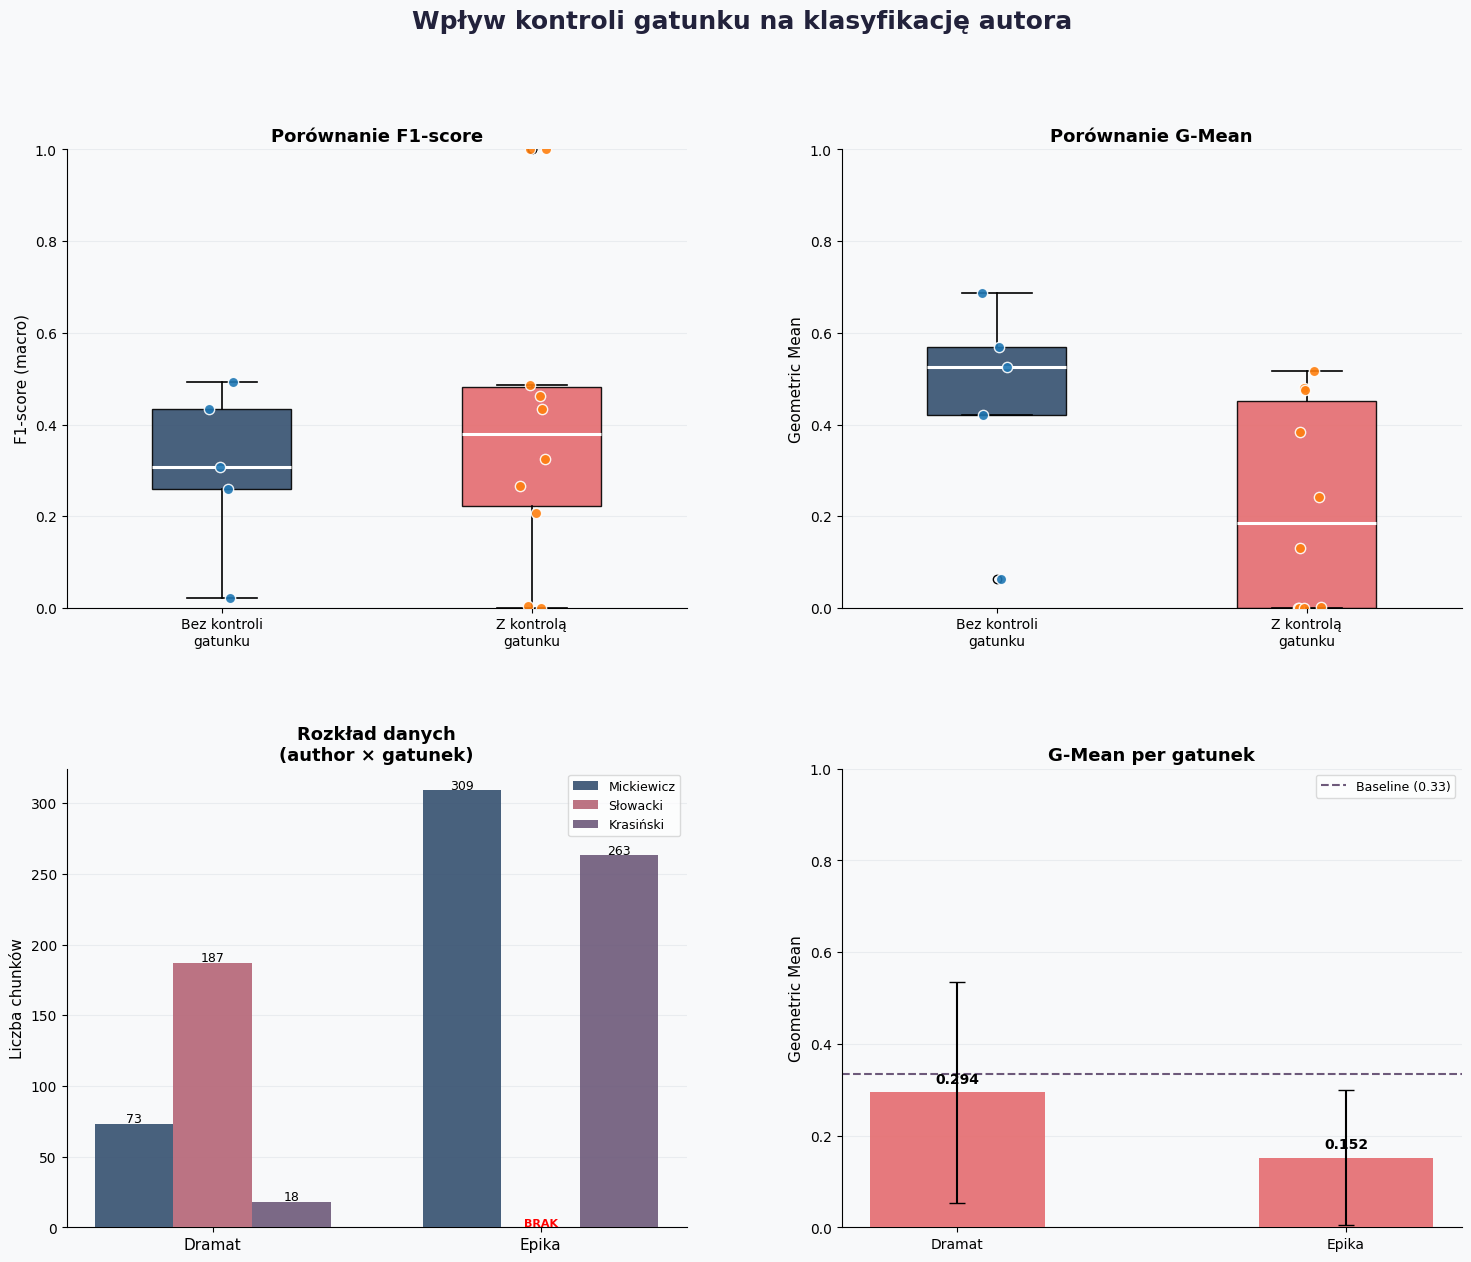

✓ Wykres zapisany: wyniki_autorstwo.png


In [12]:
plot_results(exp_result, df_chunks)

## Problemy
* Słowacki x Epika - brak
* Silne niezbalansowanie klas

## Interpretacja
Uzyskane wyniki wskazują, że kontrola gatunku literackiego zwiększyła średni wynik F1-score z 0.303 do 0.443, co sugeruje, że modele uczone i testowane w obrębie tego samego gatunku lepiej rozpoznają cechy stylometryczne autorów. 

Jednocześnie wartość geometric mean spadła z 0.453 do 0.294, co może wskazywać na większą niestabilność klasyfikacji pomiędzy poszczególnymi klasami oraz wpływ niezbalansowania danych. 

Testy statystyczne (paired t-test oraz Wilcoxona) nie wykazały jednak istotnych różnic pomiędzy wariantami ($p > 0.05$), dlatego nie ma podstaw do odrzucenia hipotezy zerowej. Dodatkowo należy zauważyć, że brak kombinacji Juliusz_Słowacki × Epika oraz nierównomierny rozkład liczby fragmentów pomiędzy gatunkami mogły wpłynąć na stabilność i wiarygodność uzyskanych wyników.


# Pytanie 2

Loading weights: 100%|██████████| 199/199 [00:00<00:00, 34433.44it/s]
[transformers] BertModel LOAD REPORT from: allegro/herbert-base-cased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.decoder.weight             | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.sso.sso_relationship.weight            | UNEXPECTED |  | 
cls.predictions.decoder.bias               | UNEXPECTED |  | 
cls.sso.sso_relationship.bias              | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


HerBERT działa na: cpu
Budowanie chunków...
Chunki: 850
TF-IDF...
Doc2Vec...
(850, 300)
HerBERT...
  HerBERT: 0/850
  HerBERT: 160/850
  HerBERT: 320/850
  HerBERT: 480/850
  HerBERT: 640/850
  HerBERT: 800/850
(850, 768)
  reprezentacja  within_mean  within_std  between_mean  between_std  n_within  \
0        TF-IDF     0.038584    0.030049      0.028497     0.016988    129502   
1       Doc2Vec     0.410983    0.214880      0.256939     0.183933    129502   
2       HerBERT     0.985921    0.015555      0.985927     0.014619    129502   

   n_between             U  p_value  effect_r  
0     231323  1.784889e+10      0.0 -0.191643  
1     231323  2.110870e+10      0.0 -0.409276  
2     231323  1.749526e+10      0.0 -0.168033  


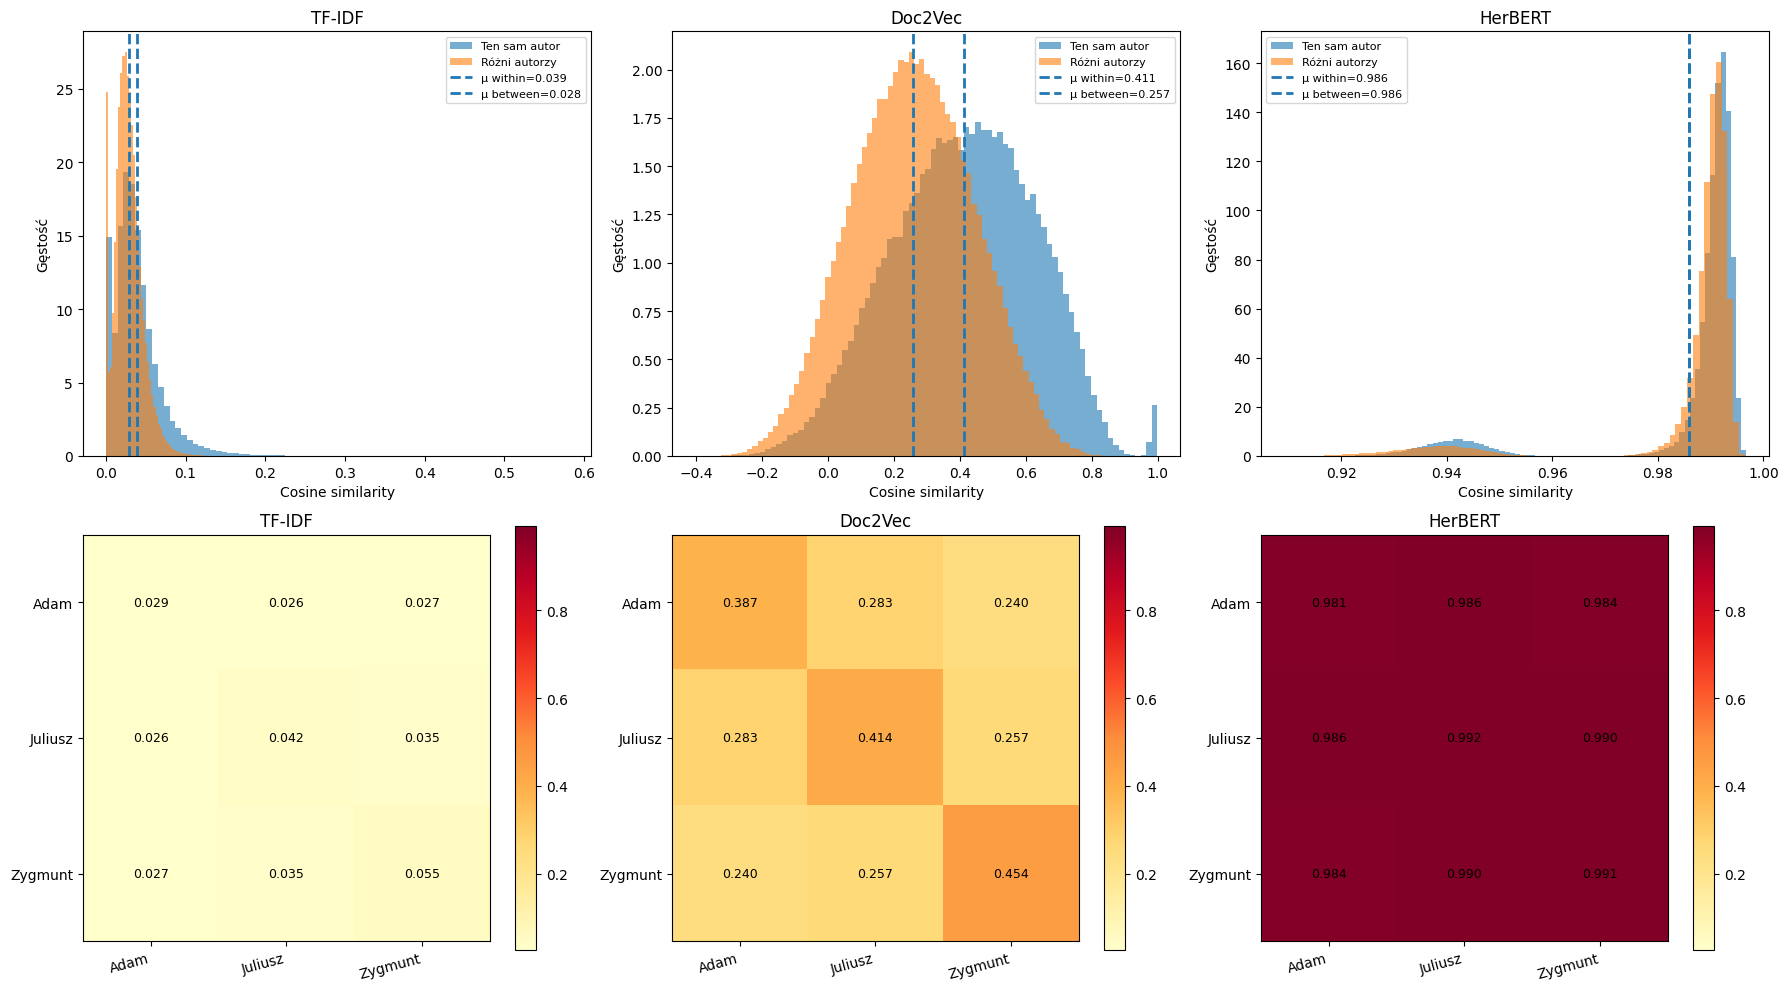


INTERPRETACJA WYNIKÓW

Reprezentacja: TF-IDF

within-author:
  0.0386
  ± 0.0300

between-author:
  0.0285
  ± 0.0170

Dyskryminowalność:
  +0.0101

Mann-Whitney:
  U=17848894840
  p=0.0000e+00

Effect size:
  r=-0.192

→ ISTOTNA


Reprezentacja: Doc2Vec

within-author:
  0.4110
  ± 0.2149

between-author:
  0.2569
  ± 0.1839

Dyskryminowalność:
  +0.1540

Mann-Whitney:
  U=21108695040
  p=0.0000e+00

Effect size:
  r=-0.409

→ ISTOTNA


Reprezentacja: HerBERT

within-author:
  0.9859
  ± 0.0156

between-author:
  0.9859
  ± 0.0146

Dyskryminowalność:
  -0.0000

Mann-Whitney:
  U=17495261184
  p=0.0000e+00

Effect size:
  r=-0.168

→ ISTOTNA



In [14]:
import pandas as pd

from scipy.stats import mannwhitneyu

from sklearn.feature_extraction.text import TfidfVectorizer

from pytania_badawcze.pytanie_2.preprocessing import (
    build_chunk_dataset
)

from pytania_badawcze.pytanie_2.evaluation import (
    get_herbert_embeddings,
    get_doc2vec_embeddings,
    pairwise_similarities,
    run_stats,
    mean_pairwise_per_author_pair,
    pairs_to_matrix,
)

from pytania_badawcze.pytanie_2.plot import (
    plot_results
)

# ============================================================
# CHUNKI
# ============================================================

print("Budowanie chunków...")

df_chunks = build_chunk_dataset(df)

print(
    f"Chunki: {len(df_chunks)}"
)

# ============================================================
# TF-IDF
# ============================================================

print("TF-IDF...")

tfidf = TfidfVectorizer(
    analyzer="word",
    ngram_range=(1, 1),
)

X_tfidf = tfidf.fit_transform(
    df_chunks["text"]
)

# ============================================================
# DOC2VEC
# ============================================================

print("Doc2Vec...")

X_doc2vec = get_doc2vec_embeddings(
    df_chunks["text"].tolist()
)

print(X_doc2vec.shape)

# ============================================================
# HERBERT
# ============================================================

print("HerBERT...")

X_herbert = get_herbert_embeddings(
    df_chunks["text"].tolist()
)

print(X_herbert.shape)

# ============================================================
# SIMILARITIES
# ============================================================

within_tfidf, between_tfidf = (
    pairwise_similarities(
        X_tfidf,
        df_chunks["author"].values,
        is_sparse=True,
    )
)

within_doc2vec, between_doc2vec = (
    pairwise_similarities(
        X_doc2vec,
        df_chunks["author"].values,
    )
)

within_herbert, between_herbert = (
    pairwise_similarities(
        X_herbert,
        df_chunks["author"].values,
    )
)

# ============================================================
# STATS
# ============================================================

stats_per_repr = pd.DataFrame([
    run_stats(
        within_tfidf,
        between_tfidf,
        "TF-IDF",
    ),

    run_stats(
        within_doc2vec,
        between_doc2vec,
        "Doc2Vec",
    ),

    run_stats(
        within_herbert,
        between_herbert,
        "HerBERT",
    ),
])

print(stats_per_repr)

# ============================================================
# AUTHOR PAIRS
# ============================================================

authors = df_chunks["author"].unique()

pair_tfidf = mean_pairwise_per_author_pair(
    X_tfidf,
    df_chunks["author"].values,
    authors,
    is_sparse=True,
)

pair_doc2vec = mean_pairwise_per_author_pair(
    X_doc2vec,
    df_chunks["author"].values,
    authors,
)

pair_herbert = mean_pairwise_per_author_pair(
    X_herbert,
    df_chunks["author"].values,
    authors,
)

mat_tfidf = pairs_to_matrix(
    pair_tfidf,
    authors,
)

mat_doc2vec = pairs_to_matrix(
    pair_doc2vec,
    authors,
)

mat_herbert = pairs_to_matrix(
    pair_herbert,
    authors,
)

# ============================================================
# LABELS
# ============================================================

short = {
    a: a.split("_")[0]
    for a in authors
}

xlabels = [
    short[a]
    for a in authors
]

# ============================================================
# PLOTS
# ============================================================

similarity_data = {
    "TF-IDF": (
        within_tfidf,
        between_tfidf,
    ),

    "Doc2Vec": (
        within_doc2vec,
        between_doc2vec,
    ),

    "HerBERT": (
        within_herbert,
        between_herbert,
    ),
}

matrices = {
    "TF-IDF": mat_tfidf,
    "Doc2Vec": mat_doc2vec,
    "HerBERT": mat_herbert,
}

plot_results(
    similarity_data,
    matrices,
    authors,
    xlabels,
    stats_per_repr,
)

Uzyskane wyniki wskazują, że wybór reprezentacji tekstu istotnie wpływa na możliwość wykrywania podobieństwa stylistycznego między autorami. Najlepsze rezultaty uzyskano dla reprezentacji Doc2Vec, która osiągnęła najwyższą różnicę pomiędzy podobieństwem fragmentów tego samego autora a fragmentów różnych autorów ($\Delta = 0.154$), a także największy efekt statystyczny ($r=-0.409$). Oznacza to, że embeddingi Doc2Vec najlepiej rozróżniały styl poszczególnych autorów. Reprezentacja TF-IDF również wykazała istotne statystycznie różnice między grupami, jednak dyskryminowalność była wyraźnie niższa ($\Delta = 0.010$), co sugeruje ograniczoną zdolność klasycznej reprezentacji worka słów do uchwycenia cech stylistycznych. Z kolei embeddingi HerBERT osiągnęły niemal identyczne średnie podobieństwa dla par within-author i between-author ($\approx 0.986$), co wskazuje na bardzo słabą zdolność separacji autorów w zastosowanej konfiguracji. Prawdopodobnie wynika to z dużej ogólności embeddingów kontekstowych oraz efektu „compression”, w którym reprezentacje różnych fragmentów tekstu stają się nadmiernie podobne w przestrzeni wektorowej. Pomimo istotności statystycznej testów Mann–Whitneya dla wszystkich reprezentacji, należy zauważyć, że przy bardzo dużej liczbie porównań nawet niewielkie różnice osiągają istotność, dlatego kluczowa pozostaje interpretacja wielkości efektu oraz różnic średnich.


# Pytanie 3

Budowanie datasetu cech...
  spaCy: 0/213 wierszy...
  spaCy: 10/213 wierszy...
  spaCy: 20/213 wierszy...
  spaCy: 30/213 wierszy...
  spaCy: 40/213 wierszy...
  spaCy: 50/213 wierszy...
  spaCy: 60/213 wierszy...
  spaCy: 70/213 wierszy...
  spaCy: 80/213 wierszy...
  spaCy: 90/213 wierszy...
  spaCy: 100/213 wierszy...
  spaCy: 110/213 wierszy...
  spaCy: 120/213 wierszy...
  spaCy: 130/213 wierszy...
  spaCy: 140/213 wierszy...
  spaCy: 150/213 wierszy...
  spaCy: 160/213 wierszy...
  spaCy: 170/213 wierszy...
  spaCy: 180/213 wierszy...
  spaCy: 190/213 wierszy...
  spaCy: 200/213 wierszy...
  spaCy: 210/213 wierszy...
Gotowe: 1477 fragmentów, 52 kolumn
Cechy leksykalne: 28
Cechy składniowe: 17
Użyta liczba foldów: 3

Klasyfikacja — cechy leksykalne...
Klasyfikacja — cechy składniowe...

=== Wyniki klasyfikacji ===
    zestaw  f1_mean   f1_std  acc_mean  acc_std  gmean_mean  gmean_std
Leksykalne 0.443745 0.074050  0.449198 0.057363    0.470894   0.071529
Składniowe 0.548825 0.0305

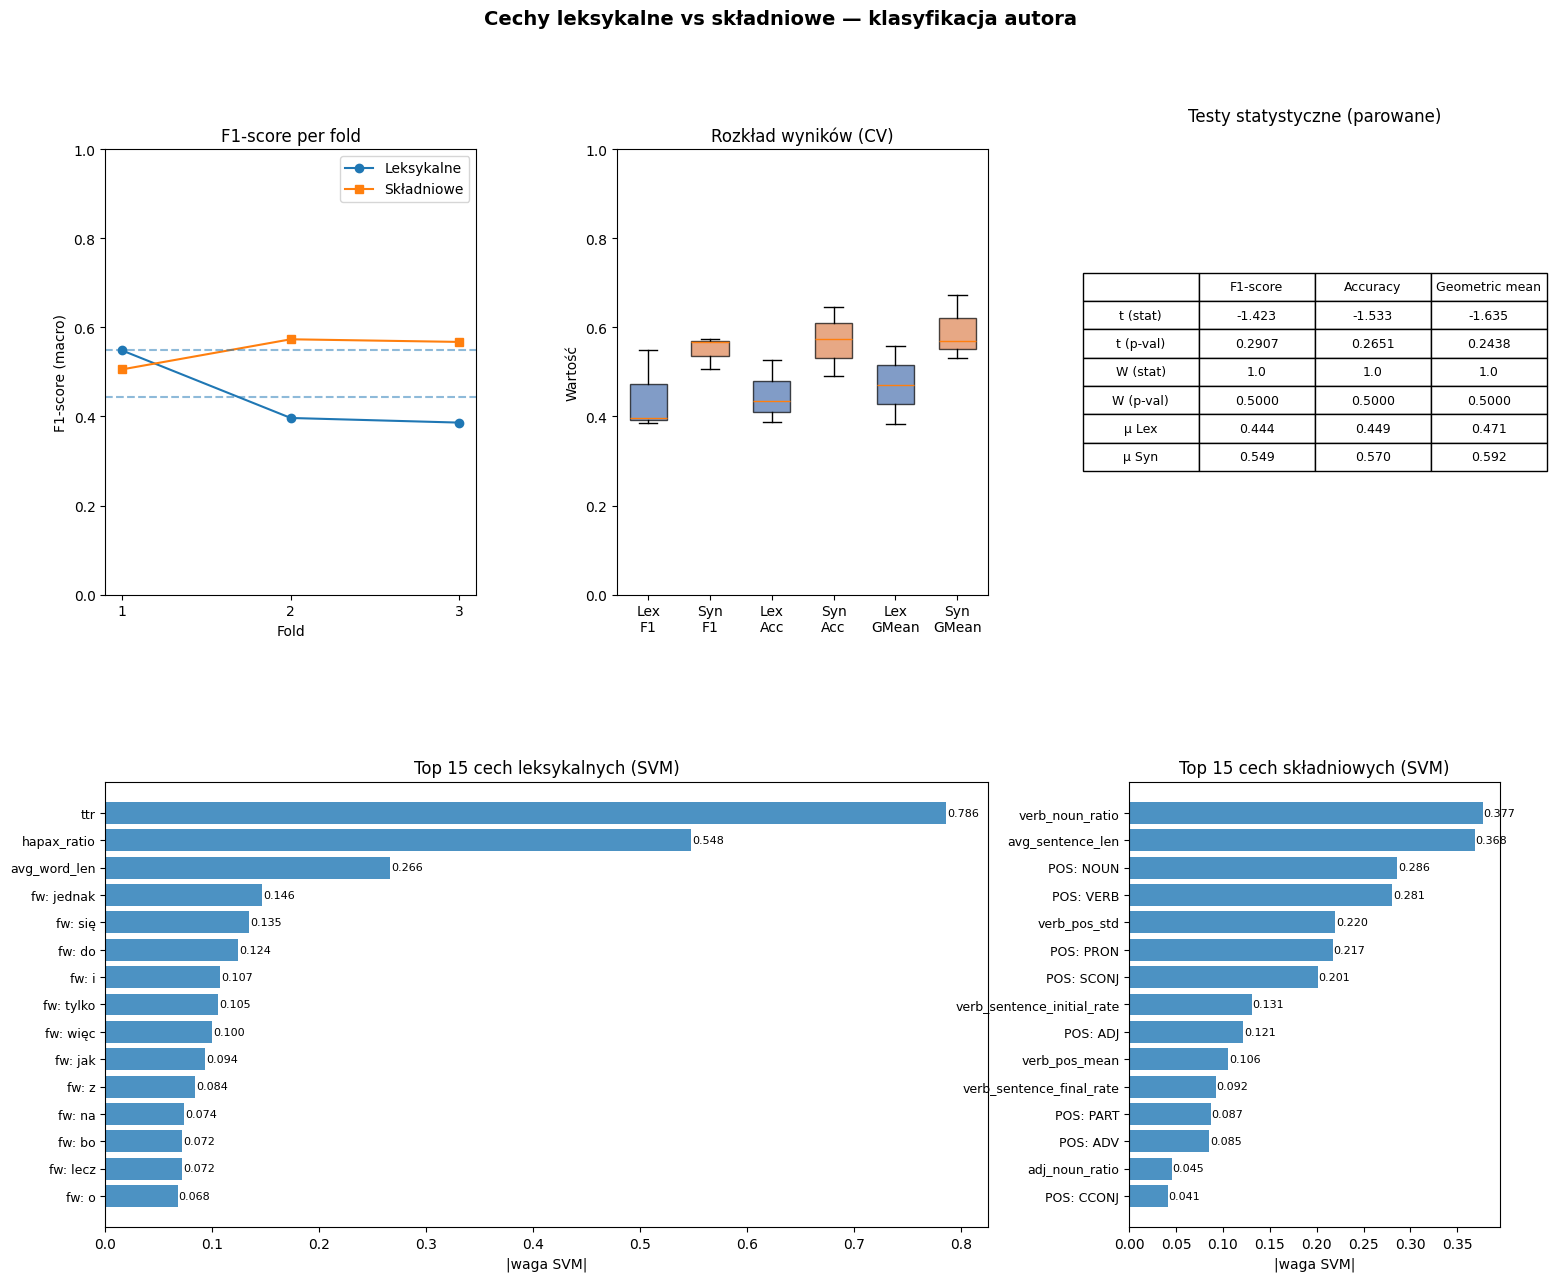

In [7]:
from pytania_badawcze.pytanie_3.preprocessing import load_nlp, build_feature_dataset
from pytania_badawcze.pytanie_3.evaluation import (
    build_cv_splits,
    get_feature_columns,
    evaluate_feature_set,
    get_feature_importance,
)
from pytania_badawcze.pytanie_3.plot import plot_result

import numpy as np
import pandas as pd
from scipy.stats import ttest_rel, wilcoxon

# 1. NLP
nlp = load_nlp("pl_core_news_sm")

# 2. Budowa datasetu cech
print("Budowanie datasetu cech...")
df_feats = build_feature_dataset(df, chunk_size=200, nlp=nlp)
print(f"Gotowe: {len(df_feats)} fragmentów, {df_feats.shape[1]} kolumn")

# 3. Podział cech
lex_cols, syn_cols = get_feature_columns(df_feats)
print(f"Cechy leksykalne: {len(lex_cols)}")
print(f"Cechy składniowe: {len(syn_cols)}")

# 4. Wspólne splity CV
N_SPLITS = 5
splits, effective_splits = build_cv_splits(
    df_feats,
    n_splits=N_SPLITS,
    group_col="work_id",
    target_col="author",
    random_state=42,
)
print(f"Użyta liczba foldów: {effective_splits}")

# 5. Ewaluacja
print("\nKlasyfikacja — cechy leksykalne...")
f1_lex, acc_lex, gmean_lex = evaluate_feature_set(
    df_feats, lex_cols, splits=splits, target_col="author"
)

print("Klasyfikacja — cechy składniowe...")
f1_syn, acc_syn, gmean_syn = evaluate_feature_set(
    df_feats, syn_cols, splits=splits, target_col="author"
)

# 6. Testy statystyczne
t_stat_f1, t_p_f1 = ttest_rel(f1_lex, f1_syn)
t_stat_acc, t_p_acc = ttest_rel(acc_lex, acc_syn)
t_stat_gmean, t_p_gmean = ttest_rel(gmean_lex, gmean_syn)

try:
    w_stat_f1, w_p_f1 = wilcoxon(f1_lex, f1_syn)
    w_stat_acc, w_p_acc = wilcoxon(acc_lex, acc_syn)
    w_stat_gmean, w_p_gmean = wilcoxon(gmean_lex, gmean_syn)
except Exception:
    w_stat_f1 = w_p_f1 = np.nan
    w_stat_acc = w_p_acc = np.nan
    w_stat_gmean = w_p_gmean = np.nan

summary = pd.DataFrame({
    "zestaw": ["Leksykalne", "Składniowe"],
    "f1_mean": [np.mean(f1_lex), np.mean(f1_syn)],
    "f1_std": [np.std(f1_lex), np.std(f1_syn)],
    "acc_mean": [np.mean(acc_lex), np.mean(acc_syn)],
    "acc_std": [np.std(acc_lex), np.std(acc_syn)],
    "gmean_mean": [np.mean(gmean_lex), np.mean(gmean_syn)],
    "gmean_std": [np.std(gmean_lex), np.std(gmean_syn)],
})

stats_summary = pd.DataFrame({
    "metryka": ["F1-score", "Accuracy", "Geometric mean"],
    "t_stat": [t_stat_f1, t_stat_acc, t_stat_gmean],
    "t_pvalue": [t_p_f1, t_p_acc, t_p_gmean],
    "wilcoxon_stat": [w_stat_f1, w_stat_acc, w_stat_gmean],
    "wilcoxon_pval": [w_p_f1, w_p_acc, w_p_gmean],
})

print("\n=== Wyniki klasyfikacji ===")
print(summary.to_string(index=False))

print("\n=== Testy statystyczne (parowane) ===")
print(stats_summary.to_string(index=False))

# 7. Ważność cech
imp_lex = get_feature_importance(df_feats, lex_cols, target_col="author")
imp_syn = get_feature_importance(df_feats, syn_cols, target_col="author")

# 8. Wykres
plot_result(
    f1_lex, f1_syn,
    acc_lex, acc_syn,
    gmean_lex, gmean_syn,
    t_stat_f1, t_stat_acc, t_stat_gmean,
    t_p_f1, t_p_acc, t_p_gmean,
    w_stat_f1, w_stat_acc, w_stat_gmean,
    w_p_f1, w_p_acc, w_p_gmean,
    imp_lex, imp_syn,
    top_n=15,
    n_splits=effective_splits,
    output_path="q3_features_comparison.png",
)

Uzyskane wyniki wskazują, że cechy składniowe były skuteczniejsze od cech leksykalnych w zadaniu rozpoznawania autorstwa tekstów. Model wykorzystujący cechy składniowe osiągnął wyższe średnie wartości wszystkich analizowanych metryk: \textit{F1-score} równy 0.549, \textit{accuracy} 0.570 oraz \textit{geometric mean} 0.592, podczas gdy dla cech leksykalnych wartości te wyniosły odpowiednio 0.444, 0.449 oraz 0.471. Oznacza to, że informacje związane ze strukturą składniową tekstu, takie jak rozkład części mowy czy relacje między kategoriami gramatycznymi, lepiej oddawały indywidualny styl autorów niż same właściwości słownictwa. Jednocześnie przeprowadzone testy statystyczne (test t-Studenta oraz test Wilcoxona) nie wykazały istotnych statystycznie różnic pomiędzy porównywanymi modelami ($p > 0.05$ dla wszystkich metryk). Może to wynikać z niewielkiej liczby foldów walidacji krzyżowej (3) oraz ograniczonej liczby utworów w zbiorze danych. Mimo braku podstaw do odrzucenia hipotezy zerowej, obserwowana przewaga cech składniowych sugeruje, że mają one większy potencjał w analizie stylometrycznej badanych tekstów.
